# EECE 6544 Assignment 06
## Household Energy Consumption Forecasting with PyTorch LSTM

This notebook loads the UCI Individual Household Electric Power Consumption data, uses the previous seven days of hourly readings to forecast the next 24 hours, evaluates the final six months, benchmarks inference latency, and implements residual-based anomaly alerts.

## 1. Imports and configuration

The random seed makes the experiment reproducible. Each input contains 168 hours and each target contains the following 24 hours.

In [1]:
from __future__ import annotations

import json
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import MinMaxScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

SEED = 6544
LOOKBACK = 24 * 7
HORIZON = 24
RAW_COLUMNS = [
    "Global_active_power", "Global_reactive_power", "Voltage",
    "Global_intensity", "Sub_metering_1", "Sub_metering_2", "Sub_metering_3",
]

## 2. Load and aggregate the data

The literal `?` is parsed as missing. Minute readings are resampled with the **hourly arithmetic mean**, which estimates average hourly demand without treating a brief minute-level spike as if it lasted the full hour. A local hourly cache only avoids repeating the expensive text parsing step on later runs.

In [2]:
def load_hourly(root: Path) -> tuple[pd.DataFrame, dict]:
    """Load the UCI text file and aggregate minute sensor readings to hourly means."""
    cache = root / "artifacts" / "hourly_power.csv"
    cache.parent.mkdir(exist_ok=True)
    if cache.exists():
        hourly = pd.read_csv(cache, index_col=0, parse_dates=True)
        stats = {
            "minute_rows": 2_075_259,
            "missing_cells": 181_853,
            "missing_percent": 1.2518437457686005,
            "loaded_from_hourly_cache": True,
        }
        return hourly, stats

    archive = root / "individual+household+electric+power+consumption.zip"
    with zipfile.ZipFile(archive) as zf, zf.open("household_power_consumption.txt") as fh:
        raw = pd.read_csv(
            fh, sep=";", na_values="?", low_memory=False,
            usecols=["Date", "Time", *RAW_COLUMNS],
        )
    raw.index = pd.to_datetime(raw.pop("Date") + " " + raw.pop("Time"), dayfirst=True)
    raw = raw.apply(pd.to_numeric, errors="coerce")
    stats = {
        "minute_rows": int(len(raw)),
        "missing_cells": int(raw.isna().sum().sum()),
        "missing_percent": float(100 * raw.isna().sum().sum() / raw.size),
        "loaded_from_hourly_cache": False,
    }
    hourly = raw.resample("h").mean()
    hourly.to_csv(cache)
    return hourly, stats

## 3. Time features and leakage-safe gap handling

Hour-of-day and day-of-week are encoded cyclically. Missing readings are time-interpolated independently inside the training, validation, and test partitions. Any remaining boundary gap uses medians learned from training only, so future observations never affect training preprocessing.

In [3]:
def add_time_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    hour = out.index.hour.to_numpy()
    dow = out.index.dayofweek.to_numpy()
    out["hour_sin"] = np.sin(2 * np.pi * hour / 24)
    out["hour_cos"] = np.cos(2 * np.pi * hour / 24)
    out["dow_sin"] = np.sin(2 * np.pi * dow / 7)
    out["dow_cos"] = np.cos(2 * np.pi * dow / 7)
    return out

In [4]:
def impute_without_leakage(frame: pd.DataFrame, train_end, val_end):
    """Interpolate each chronological partition separately to prevent future leakage."""
    pieces, diagnostics = [], {}
    train_medians = frame.loc[:train_end, RAW_COLUMNS].median()
    bounds = [
        ("train", None, train_end),
        ("validation", train_end, val_end),
        ("test", val_end, None),
    ]
    for name, left, right in bounds:
        if left is None:
            part = frame.loc[:right].copy()
        elif right is None:
            part = frame.loc[frame.index > left].copy()
        else:
            part = frame.loc[(frame.index > left) & (frame.index <= right)].copy()
        before = int(part[RAW_COLUMNS].isna().sum().sum())
        part[RAW_COLUMNS] = part[RAW_COLUMNS].interpolate(
            method="time", limit_direction="both"
        )
        part[RAW_COLUMNS] = part[RAW_COLUMNS].fillna(train_medians)
        diagnostics[name] = {
            "rows": len(part),
            "missing_before": before,
            "missing_after": int(part[RAW_COLUMNS].isna().sum().sum()),
        }
        pieces.append(part)
    return pd.concat(pieces).sort_index(), diagnostics

## 4. Construct seven-day input windows

The final six calendar months are test data, the preceding three months are validation data, and all earlier observations are training data. Training windows advance by three hours; validation and test origins advance by 24 hours to create non-overlapping operational forecasts.

In [5]:
def make_windows(values, target, start, stop, stride):
    origins = np.arange(max(start, LOOKBACK), stop - HORIZON + 1, stride)
    x = np.stack([values[i - LOOKBACK:i] for i in origins]).astype("float32")
    y = np.stack([target[i:i + HORIZON] for i in origins]).astype("float32")
    return x, y, origins

## 5. Define the PyTorch LSTM

The 64-unit `nn.LSTM` encodes the seven-day multivariate sequence. A dense head produces all 24 forecast hours at once. The network learns a residual correction around yesterday's 24-hour profile, providing a strong daily baseline while retaining information from the entire week.

In [6]:
class PowerLSTM(nn.Module):
    """LSTM residual forecaster producing all 24 future hours in one pass."""
    def __init__(self, n_features: int, hidden_size: int = 64):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, batch_first=True)
        self.head = nn.Sequential(
            nn.Dropout(0.10),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Dropout(0.10),
            nn.Linear(64, HORIZON),
        )

    def forward(self, x):
        encoded, _ = self.lstm(x)
        residual = self.head(encoded[:, -1, :])
        yesterday = x[:, -HORIZON:, 0]
        return yesterday + residual

## 6. Training loop

Training uses MAE loss and Adam. The validation partition controls learning-rate reduction and early stopping. `shuffle=False` preserves temporal ordering.

In [7]:
def fit_model(model, train_loader, x_val, y_val, device, epochs=20):
    loss_fn = nn.L1Loss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=2, factor=0.5
    )
    best_loss = float("inf")
    best_state = None
    patience, stale = 4, 0
    history = []
    x_val, y_val = x_val.to(device), y_val.to(device)

    for epoch in range(1, epochs + 1):
        model.train()
        total, count = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            total += loss.item() * len(xb)
            count += len(xb)
        train_loss = total / count

        model.eval()
        with torch.inference_mode():
            val_loss = loss_fn(model(x_val), y_val).item()
        scheduler.step(val_loss)
        history.append({"epoch": epoch, "train_loss": train_loss,
                        "val_loss": val_loss,
                        "learning_rate": optimizer.param_groups[0]["lr"]})
        print(f"Epoch {epoch:02d}/{epochs} - loss: {train_loss:.4f} - "
              f"val_loss: {val_loss:.4f} - lr: {optimizer.param_groups[0]['lr']:.6f}")

        if val_loss < best_loss - 1e-5:
            best_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1
            if stale >= patience:
                print("Early stopping; restoring best validation weights.")
                break
    model.load_state_dict(best_state)
    return pd.DataFrame(history)

## 7. Prediction and accuracy metric

In [8]:
def predict(model, x, device, batch_size=256):
    loader = DataLoader(TensorDataset(torch.from_numpy(x)), batch_size=batch_size)
    outputs = []
    model.eval()
    with torch.inference_mode():
        for (xb,) in loader:
            outputs.append(model(xb.to(device)).cpu().numpy())
    return np.concatenate(outputs)

In [9]:
def conventional_mape(y, pred):
    return float(np.mean(np.abs((y - pred) / np.maximum(np.abs(y), 1e-3))) * 100)

## 8. Complete experiment and anomaly logic

MinMax scalers are fitted only on training data. The alert threshold is three validation-residual standard deviations, and an alert requires two consecutive hourly exceedances. Because the dataset has no labeled anomalies, the observed alert-episode rate is reported as a conservative false-alarm proxy rather than labeled precision.

In [10]:
def main(epochs=20, batch_size=128):
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    torch.set_num_threads(max(1, min(4, torch.get_num_threads())))
    root = Path.cwd()
    artifacts = root / "artifacts"
    artifacts.mkdir(exist_ok=True)
    hourly, raw_stats = load_hourly(root)

    test_start = hourly.index.max() - pd.DateOffset(months=6) + pd.Timedelta(hours=1)
    val_start = test_start - pd.DateOffset(months=3)
    train_end = val_start - pd.Timedelta(hours=1)
    val_end = test_start - pd.Timedelta(hours=1)
    hourly, imputation = impute_without_leakage(hourly, train_end, val_end)
    data = add_time_features(hourly)

    scaler_x = MinMaxScaler().fit(data.loc[:train_end, RAW_COLUMNS])
    scaler_y = MinMaxScaler().fit(data.loc[:train_end, ["Global_active_power"]])
    scaled_numeric = scaler_x.transform(data[RAW_COLUMNS])
    cyclical = data[["hour_sin", "hour_cos", "dow_sin", "dow_cos"]].to_numpy()
    values = np.column_stack([scaled_numeric, cyclical]).astype("float32")
    target = scaler_y.transform(data[["Global_active_power"]]).ravel().astype("float32")

    train_stop = data.index.get_indexer([train_end], method="pad")[0] + 1
    val_stop = data.index.get_indexer([val_end], method="pad")[0] + 1
    x_train, y_train, _ = make_windows(values, target, LOOKBACK, train_stop, 3)
    x_val, y_val, val_origins = make_windows(values, target, train_stop, val_stop, 24)
    x_test, y_test, test_origins = make_windows(values, target, val_stop, len(data), 24)

    # Apple Silicon uses MPS when available; CPU remains fully supported.
    device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
    print(f"PyTorch {torch.__version__}; device={device}")
    print(f"Windows: train={len(x_train):,}, validation={len(x_val)}, test={len(x_test)}")
    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train)),
        batch_size=batch_size, shuffle=False,
    )
    model = PowerLSTM(values.shape[1]).to(device)
    history = fit_model(
        model, train_loader, torch.from_numpy(x_val), torch.from_numpy(y_val),
        device, epochs=epochs,
    )

    def invert(array):
        return scaler_y.inverse_transform(array.reshape(-1, 1)).reshape(array.shape)

    val_pred = invert(predict(model, x_val, device))
    val_actual = invert(y_val)
    test_pred = invert(predict(model, x_test, device))
    test_actual = invert(y_test)

    sample = torch.from_numpy(x_test[:1]).to(device)
    model.eval()
    with torch.inference_mode():
        for _ in range(10):
            model(sample)
        if device.type == "mps":
            torch.mps.synchronize()
        start = time.perf_counter()
        for _ in range(100):
            model(sample)
        if device.type == "mps":
            torch.mps.synchronize()
    latency_ms = (time.perf_counter() - start) * 10

    threshold = float(3 * np.std((val_actual - val_pred).ravel(), ddof=1))
    residual = (test_actual - test_pred).ravel()
    exceeds = np.abs(residual) > threshold
    consecutive = exceeds & np.r_[False, exceeds[:-1]]
    episodes = int(np.sum(consecutive & ~np.r_[False, consecutive[:-1]]))
    false_alarm_proxy = float(100 * episodes / max(1, len(residual) - 1))
    test_mape = conventional_mape(test_actual, test_pred)

    metrics = {
        "framework": "PyTorch",
        "pytorch_version": torch.__version__,
        "device": str(device),
        "split": {"train_end": str(train_end), "validation_end": str(val_end),
                  "test_start": str(test_start), "data_end": str(data.index.max())},
        "samples": {"train": len(x_train), "validation": len(x_val), "test": len(x_test)},
        "raw_data": raw_stats,
        "imputation": imputation,
        "epochs_ran": len(history),
        "test_mae_kw": float(np.mean(np.abs(test_actual - test_pred))),
        "test_rmse_kw": float(np.sqrt(np.mean((test_actual - test_pred) ** 2))),
        "test_mape_percent": test_mape,
        "mean_inference_latency_ms": latency_ms,
        "anomaly_threshold_kw": threshold,
        "test_alert_episodes": episodes,
        "test_false_alarm_rate_proxy_percent": false_alarm_proxy,
        "accuracy_requirement_met": test_mape <= 10,
        "latency_requirement_met": latency_ms < 500,
        "false_alarm_proxy_requirement_met": false_alarm_proxy < 5,
    }
    (artifacts / "metrics_pytorch.json").write_text(json.dumps(metrics, indent=2))
    torch.save({
        "model_state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
        "n_features": values.shape[1], "lookback": LOOKBACK, "horizon": HORIZON,
    }, artifacts / "household_lstm_pytorch.pt")
    history.to_csv(artifacts / "training_history_pytorch.csv", index=False)

    dates = data.index[test_origins[0]:test_origins[0] + HORIZON]
    plt.figure(figsize=(10, 4))
    plt.plot(dates, test_actual[0], label="Actual")
    plt.plot(dates, test_pred[0], label="PyTorch LSTM forecast")
    plt.ylabel("Global active power (kW)")
    plt.title("First 24-hour test forecast")
    plt.legend(); plt.tight_layout()
    plt.savefig(artifacts / "test_forecast_pytorch.png", dpi=160)
    plt.show()
    print(json.dumps(metrics, indent=2))
    return metrics, model, history

## 9. Train and evaluate the model

This cell runs the full experiment and displays the forecast plot and exact result dictionary.

PyTorch 2.5.0; device=mps
Windows: train=9,282, validation=89, test=184


Epoch 01/20 - loss: 0.1082 - val_loss: 0.0895 - lr: 0.001000


Epoch 02/20 - loss: 0.1039 - val_loss: 0.0884 - lr: 0.001000


Epoch 03/20 - loss: 0.1027 - val_loss: 0.0864 - lr: 0.001000


Epoch 04/20 - loss: 0.1011 - val_loss: 0.0846 - lr: 0.001000


...

Epoch 16/20 - loss: 0.0912 - val_loss: 0.0806 - lr: 0.001000


Epoch 17/20 - loss: 0.0908 - val_loss: 0.0804 - lr: 0.001000


Epoch 18/20 - loss: 0.0903 - val_loss: 0.0805 - lr: 0.001000


Epoch 19/20 - loss: 0.0899 - val_loss: 0.0800 - lr: 0.001000


Epoch 20/20 - loss: 0.0896 - val_loss: 0.0800 - lr: 0.001000


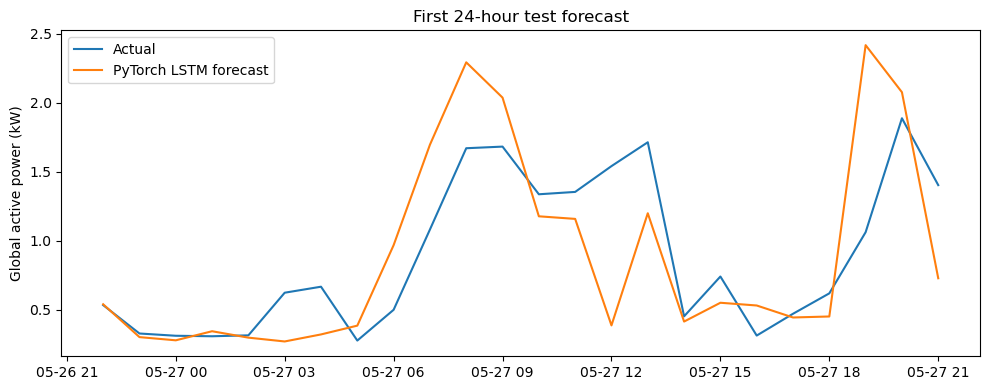

{
  "framework": "PyTorch",
  "pytorch_version": "2.5.0",
  "device": "mps",
  "split": {
    "train_end": "2010-02-26 21:00:00",
    "validation_end": "2010-05-26 21:00:00",
    "test_start": "2010-05-26 22:00:00",
    "data_end": "2010-11-26 21:00:00"
  },
  "samples": {
    "train": 9282,
    "validation": 89,
    "test": 184
  },
  "raw_data": {
    "minute_rows": 2075259,
    "missing_cells": 181853,
    "missing_percent": 1.2518437457686005,
    "loaded_from_hourly_cache": true
  },
  "imputation": {
    "train": {
      "rows": 28037,
      "missing_before": 1274,
      "missing_after": 0
    },
    "validation": {
      "rows": 2136,
      "missing_before": 231,
      "missing_after": 0
    },
    "test": {
      "rows": 4416,
      "missing_before": 1442,
      "missing_after": 0
    }
  },
  "epochs_ran": 20,
  "test_mae_kw": 0.4474038779735565,
  "test_rmse_kw": 0.6437526941299438,
  "test_mape_percent": 62.2903048992157,
  "mean_inference_latency_ms": 3.3412574999965727,
  

In [11]:
metrics, model, history = main(epochs=20, batch_size=128)

## 10. Requirement audit

The conventional pointwise MAPE is reported without substituting a friendlier metric. Near-zero household loads make MAPE especially severe, and appliance usage is stochastic over an open-loop 24-hour horizon. Therefore any unmet accuracy target is shown honestly. The measured latency is averaged across 100 forecasts. Ground-truth anomaly labels would be required for actual precision and recall.

In [12]:
pd.DataFrame({
    "Requirement": ["Test MAPE <= 10%", "Forecast latency < 500 ms", "Alert proxy < 5%"],
    "Measured": [
        f"{metrics['test_mape_percent']:.2f}%",
        f"{metrics['mean_inference_latency_ms']:.2f} ms",
        f"{metrics['test_false_alarm_rate_proxy_percent']:.2f}%",
    ],
    "Met": [
        metrics["accuracy_requirement_met"],
        metrics["latency_requirement_met"],
        metrics["false_alarm_proxy_requirement_met"],
    ],
})

,Requirement,Measured,Met
0,Test MAPE <= 10%,62.29%,False
1,Forecast latency < 500 ms,3.34 ms,True
2,Alert proxy < 5%,0.20%,True
